<h4>Assessment 2 - Brief</h4>

* Analytic question formulation
* Data wrangling
* Data preparation and sampling
* Descriptive statistics
* Inferential statistics (Confidence interval)
* Inferential statistics (Two-sample t-Test)

<h4><strong>Question for analysis</strong></h4>
Do goalkeepers with higher aggression (more actions outside the penalty area) have significantly different save efficiency compared to less aggressive goalkeepers? Nb. only goalkeeper that played in FIFA world cup 2026.

<h5>Thought's question - Are aggressive keepers:</h5>

1. more efficient shot‑stoppers ?
2. or less efficient ?
3. or no different at all ?

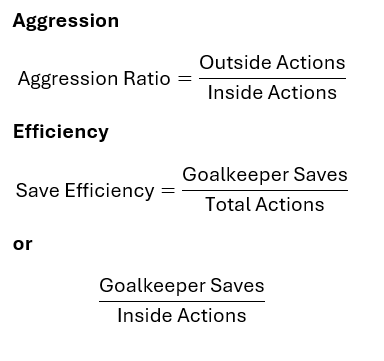

Note: 
- We are to work with sample data calculate t sample stats (sample size to be min 30-40 players)
- the sample size of goalkeeper.csv = 61 goalkeepers 

1. Assign each player an id
3. Calculate confidence interval - CI - Inferential stat
4. What confidence level - we are using 95%
5. Create a sample T test - compared to previous years 2022 world cup - goalkeeper statistics
6. Hypothesis testing - Inferential stat (two-sample T test) 2022 sample vs 2026 sample - goalkeeper statistics
8. Create powerpoint of analysis of Goalkeeper process to answer question
9. Create video for youtube of analysis. Then upload to github repository - name: HIT140_Assessment-2_Group23 - https://github.com/DanDooLoo/HIT140_Assessment-2_Group23

<h4>Sample for point 1.:</h4>

Assign each player an id. 

The code I will use is:
- gk["Player_ID"] = gk.index + 1

<h4>Sample for point 2.:</h4>

To create a sample from goalkeeper 2026 and 2022 FIFA World Cup - Sample to randomly select 30 rows from dataset size of 61 rows

The code I will use is:
code is: 
- sample_gk_t_test_2026 = goalkeeper.sample(n=30, random_state=42)

Note: random_state=42 is a seed for the random number generator

In [124]:
# import required packages for stat analysis
import pandas as pd
import numpy as np
from scipy import stats as st
import statsmodels.stats.weightstats as stm
import math
import matplotlib.pyplot as plt
from scipy.stats import norm

# read in data collected from FIFA Official website
gk = pd.read_csv("goalkeeper.csv")
gk["Player_ID"] = gk.index + 1


In [125]:
gk.head()

,Rank,Player,Team,Position,Goalkeeper_Saves,Goalkeeper_Actions_inside_PenaltyArea,Goalkeeper_Actions_outside_PenaltyArea,Player_ID
0,1,Orlando Gill,PAR,GK,28,141,124,1
1,2,Eloy Room,CUW,GK,21,81,72,2
2,3,Emiliano Martinez,ARG,GK,20,111,97,3
3,3,Gregor Kobel,SUI,GK,20,100,88,4
4,3,Diogo Costa,POR,GK,20,114,93,5


In [126]:
gk_sample = gk.sample(30, random_state=42)

In [127]:
gk_sample.head()

,Rank,Player,Team,Position,Goalkeeper_Saves,Goalkeeper_Actions_inside_PenaltyArea,Goalkeeper_Actions_outside_PenaltyArea,Player_ID
69,58,Paul Izzo,AUS,GK,0,0,0,70
140,58,Geronimo Rulli,ARG,GK,0,0,0,141
27,28,Yahia Fofana,CIV,GK,11,84,68,28
19,20,Mostafa Shoubir,EGY,GK,14,119,105,20
42,43,Camilo Vargas,COL,GK,7,57,54,43


In [128]:
gk_sample.describe()

,Rank,Goalkeeper_Saves,Goalkeeper_Actions_inside_PenaltyArea,Goalkeeper_Actions_outside_PenaltyArea,Player_ID
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,46.533333,4.266667,27.433333,23.366667,74.600000
std,17.715634,6.274927,37.971571,32.571919,42.175822
min,9.000000,0.000000,0.000000,0.000000,10.000000
25%,37.750000,0.000000,0.000000,0.000000,38.500000
50%,58.000000,0.000000,0.000000,0.000000,75.500000
75%,58.000000,7.750000,57.000000,47.500000,111.250000
max,58.000000,17.000000,119.000000,105.000000,141.000000


In [129]:
gk_sample.info()

<class 'pandas.DataFrame'>
Index: 30 entries, 69 to 9
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   Rank                                    30 non-null     int64
 1   Player                                  30 non-null     str  
 2   Team                                    30 non-null     str  
 3   Position                                30 non-null     str  
 4   Goalkeeper_Saves                        30 non-null     int64
 5   Goalkeeper_Actions_inside_PenaltyArea   30 non-null     int64
 6   Goalkeeper_Actions_outside_PenaltyArea  30 non-null     int64
 7   Player_ID                               30 non-null     int64
dtypes: int64(5), str(3)
memory usage: 2.1 KB


<strong><h3>Analysis: Step 1 - Separate goalkeepers into high and low aggression groups</h3></strong>
1. High aggression group → above median aggression ratio
2. Low aggression group → below median aggression ratio


In [130]:
# Step 1:
# group goalkeepers into high and low aggression and save efficiency
# create variables
gk_sample["Aggression_Ratio"] = gk_sample["Goalkeeper_Actions_outside_PenaltyArea"] / gk_sample["Goalkeeper_Actions_inside_PenaltyArea"]
gk_sample["Save_Efficiency"] = gk_sample["Goalkeeper_Saves"] / (gk_sample["Goalkeeper_Actions_inside_PenaltyArea"] + gk_sample["Goalkeeper_Actions_outside_PenaltyArea"])


In [131]:
# Step 2.1:
# create medians to be able to sort goalkeepers into high and low group - aggression
median_aggression = gk_sample["Aggression_Ratio"].median()

In [132]:
# Step 2.2:
# create medians to be able to sort goalkeepers into high and low group - save
median_save = gk_sample["Save_Efficiency"].median()

In [133]:
# Step 3.1: --
# create high and low grouping of goalkeepers - aggression
high_aggression = gk_sample[gk_sample["Aggression_Ratio"] > median_aggression]
low_aggression = gk_sample[gk_sample["Aggression_Ratio"] <= median_aggression]

In [134]:
# Step 3.2: --
# create high and low grouping of goalkeepers - save
high_save = gk_sample[gk_sample["Save_Efficiency"] > median_save]
low_save = gk_sample[gk_sample["Save_Efficiency"] <= median_save]

In [135]:
# Review check point 1.1: - aggression
# check if it actually worked
print("High aggression group size: ", len(high_aggression))
print("Low aggression group size: ", len(low_aggression))

High aggression group size:  6
Low aggression group size:  6


In [136]:
# Review check point 1.2: - save
# check if it actually worked
print("High save group size: ", len(high_save))
print("Low save group size: ", len(low_save))

High save group size:  6
Low save group size:  6


In [137]:
# Review check point 2.1: - aggression
# check if it actually worked - display header rows
high_aggression[["Player", "Team", "Aggression_Ratio"]].head()


,Player,Team,Aggression_Ratio
19,Mostafa Shoubir,EGY,0.882353
42,Camilo Vargas,COL,0.947368
18,Alisson,BRA,0.880597
11,Bart Verbruggen,NED,0.947368
51,Fernando Muslera,URU,0.829268


In [138]:
# Review check point 2.2: - save
# check if it actually worked - display header rows
high_save[["Player", "Team", "Save_Efficiency"]].head()

,Player,Team,Save_Efficiency
18,Alisson,BRA,0.119048
12,Thibaut Courtois,BEL,0.085000
36,Raul Rangel,MEX,0.077670
11,Bart Verbruggen,NED,0.153153
31,Matt Freese,USA,0.094340


In [139]:
# Review check point 3.1: - aggression
# check if it actually worked - display header rows
low_aggression[["Player", "Team", "Aggression_Ratio"]].head()

,Player,Team,Aggression_Ratio
27,Yahia Fofana,CIV,0.809524
12,Thibaut Courtois,BEL,0.818182
55,Mouhib Chamakh,TUN,0.769231
36,Raul Rangel,MEX,0.807018
31,Matt Freese,USA,0.827586


In [140]:
# Review check point 3.2: - save
# check if it actually worked - display header rows
low_save[["Player", "Team", "Save_Efficiency"]].head()

,Player,Team,Save_Efficiency
27,Yahia Fofana,CIV,0.072368
19,Mostafa Shoubir,EGY,0.062500
42,Camilo Vargas,COL,0.063063
55,Mouhib Chamakh,TUN,0.021739
45,Manuel Neuer,GER,0.066038


In [141]:
high_aggression.describe()


,Rank,Goalkeeper_Saves,Goalkeeper_Actions_inside_PenaltyArea,Goalkeeper_Actions_outside_PenaltyArea,Player_ID,Aggression_Ratio,Save_Efficiency
count,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,24.666667,12.333333,71.166667,64.000000,26.000000,0.898989,0.092459
std,18.381150,5.501515,27.701384,24.503061,17.332051,0.045213,0.039519
min,9.000000,4.000000,41.000000,34.000000,10.000000,0.829268,0.053333
25%,10.500000,8.750000,57.000000,54.000000,13.750000,0.881036,0.062641
50%,17.500000,14.500000,62.000000,56.500000,19.500000,0.894665,0.083361
75%,37.250000,16.500000,81.250000,73.250000,37.250000,0.937271,0.115200
max,52.000000,17.000000,119.000000,105.000000,52.000000,0.947368,0.153153


In [142]:
low_aggression.describe()

,Rank,Goalkeeper_Saves,Goalkeeper_Actions_inside_PenaltyArea,Goalkeeper_Actions_outside_PenaltyArea,Player_ID,Aggression_Ratio,Save_Efficiency
count,6.00000,6.00000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,34.00000,9.00000,66.000000,52.833333,35.333333,0.794874,0.069526
std,15.70987,5.25357,28.390139,23.752193,14.881756,0.034355,0.025398
min,9.00000,1.00000,26.000000,20.000000,13.000000,0.737705,0.021739
25%,29.00000,7.25000,57.250000,45.250000,29.000000,0.778677,0.067620
50%,34.00000,9.00000,59.500000,47.000000,34.500000,0.808271,0.075019
75%,41.25000,10.75000,78.250000,63.000000,43.750000,0.816017,0.083167
max,56.00000,17.00000,110.000000,90.000000,56.000000,0.827586,0.094340


In [143]:
high_save.describe()

,Rank,Goalkeeper_Saves,Goalkeeper_Actions_inside_PenaltyArea,Goalkeeper_Actions_outside_PenaltyArea,Player_ID,Aggression_Ratio,Save_Efficiency
count,6.000000,6.00,6.000000,6.000000,6.000000,6.000000,6.000000
mean,18.333333,14.00,72.500000,62.500000,20.500000,0.864621,0.105478
std,12.420413,4.00,21.491859,17.683325,11.362218,0.056112,0.027485
min,9.000000,8.00,57.000000,46.000000,10.000000,0.807018,0.077670
25%,9.000000,11.25,57.250000,49.500000,12.250000,0.820533,0.087335
50%,12.000000,16.00,62.500000,56.500000,16.000000,0.854092,0.098999
75%,27.750000,17.00,81.250000,73.250000,28.750000,0.900382,0.115200
max,36.000000,17.00,110.000000,90.000000,37.000000,0.947368,0.153153


In [144]:
low_save.describe()

,Rank,Goalkeeper_Saves,Goalkeeper_Actions_inside_PenaltyArea,Goalkeeper_Actions_outside_PenaltyArea,Player_ID,Aggression_Ratio,Save_Efficiency
count,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,40.333333,7.333333,64.666667,54.333333,40.833333,0.829242,0.056507
std,13.866026,4.676181,33.025243,29.776949,14.034481,0.076346,0.018112
min,20.000000,1.000000,26.000000,20.000000,20.000000,0.737705,0.021739
25%,31.750000,4.750000,45.000000,36.750000,31.750000,0.779304,0.055625
50%,43.000000,7.000000,59.000000,49.500000,44.500000,0.819396,0.062782
75%,49.750000,10.000000,78.250000,64.500000,50.500000,0.869082,0.065294
max,56.000000,14.000000,119.000000,105.000000,56.000000,0.947368,0.072368


<strong><h3>Analysis: Step 2 - Create descriptive stats for high and low aggression groups</h3></strong>

I will now calculate the following descriptive statistics for goalkeeper high and low aggression

- mean
- median
- standard deviation
- sample size (n)

In [145]:
# Descriptive stats - mean, median, std dev for high aggression goalkeepers - Aggression ratio
high_aggression_mean = high_aggression["Aggression_Ratio"].mean()
high_aggression_median = high_aggression["Aggression_Ratio"].median()
high_aggression_std = high_aggression["Aggression_Ratio"].std()
high_aggression_n = len(high_aggression)

In [146]:
# Descriptive stats - mean, median, std dev for low aggression goalkeepers - Aggression ratio
low_aggression_mean = low_aggression["Aggression_Ratio"].mean()
low_aggression_median = low_aggression["Aggression_Ratio"].median()
low_aggression_std = low_aggression["Aggression_Ratio"].std()
low_aggression_n = len(low_aggression)

In [147]:
# Build a table (DataFrame) from calculated stats - Aggression Ratio
stats_table_aggression = pd.DataFrame({
    "Group": ["High Aggression", "Low Aggression"],
    "Mean Aggression Ratio": [high_aggression_mean, low_aggression_mean],
    "Median Aggression Ratio": [high_aggression_median, low_aggression_median],
    "Std Dev Aggression Ratio": [high_aggression_std, low_aggression_std],
    "N Goalkeepers": [high_aggression_n, low_aggression_n]
})

print(stats_table_aggression)

             Group  Mean Aggression Ratio  Median Aggression Ratio  \
0  High Aggression               0.898989                 0.894665   
1   Low Aggression               0.794874                 0.808271   

   Std Dev Aggression Ratio  N Goalkeepers  
0                  0.045213              6  
1                  0.034355              6  


In [148]:
# Descriptive stats - mean, median, std dev for high aggression goalkeepers - Save efficiency
high_save_mean = high_save["Save_Efficiency"].mean()
high_save_median = high_save["Save_Efficiency"].median()
high_save_std = high_save["Save_Efficiency"].std()
high_save_n = len(high_save)

In [149]:
# Descriptive stats - mean, median, std dev for low aggression goalkeepers - Save efficiency
low_save_mean = low_save["Save_Efficiency"].mean()
low_save_median = low_save["Save_Efficiency"].median()
low_save_std = low_save["Save_Efficiency"].std()
low_save_n = len(low_save)

In [150]:
# Build a table (DataFrame) from calculated stats - Save efficiency
stats_table_save = pd.DataFrame({
    "Group": ["High Save Efficiency", "Low Save Efficiency"],
    "Mean Save Efficiency": [high_save_mean, low_save_mean],
    "Median Save Efficiency": [high_save_median, low_save_median],
    "Std Dev Save Efficiency": [high_save_std, low_save_std],
    "N Goalkeepers": [high_save_n, low_save_n]
})

print(stats_table_save)


                  Group  Mean Save Efficiency  Median Save Efficiency  \
0  High Save Efficiency              0.105478                0.098999   
1   Low Save Efficiency              0.056507                0.062782   

   Std Dev Save Efficiency  N Goalkeepers  
0                 0.027485              6  
1                 0.018112              6  


In [151]:
stats_table_save.style.format({
    "Mean Save Efficiency": "{:.3f}",
    "Median Save Efficiency": "{:.3f}",
    "Std Dev Save Efficiency": "{:.3f}"
})



,Group,Mean Save Efficiency,Median Save Efficiency,Std Dev Save Efficiency,N Goalkeepers
0,High Save Efficiency,0.105,0.099,0.027,6
1,Low Save Efficiency,0.057,0.063,0.018,6


In [152]:
print(stats_table_save.dtypes)


Group                          str
Mean Save Efficiency       float64
Median Save Efficiency     float64
Std Dev Save Efficiency    float64
N Goalkeepers                int64
dtype: object


<strong><h4>Analysis: Step 3 - Compute confidence intervals (CI)</h4></strong>

I will be using a 95% CI for the goalkeeper groups - high and low
 
The general formula for a confidence interval around a mean is:
CI = X̄ ± (Z × (s / √n))

Where:

X̄ is the sample mean.

Z is the Z-score corresponding to the confidence level (e.g., 1.96 for 95% confidence).

s is the sample standard deviation.

n is the sample size.

<h4> Create visuals for aggression ratio </h4>

In [153]:
# calculation confidence interval goalkeeper high aggression
ci_low, ci_upp = stm._zconfint_generic(high_aggression_mean, high_aggression_n / math.sqrt(high_aggression_n), alpha=0.05, alternative='two-sided') # 95% confidence interval alpha=0.05 or 5%
print("CI high aggression goalkeepers: %.2f to %.2f" % (ci_low, ci_upp)) 

CI high aggression goalkeepers: -3.90 to 5.70


In [154]:
# calculation confidence interval goalkeeper low aggression
ci_low, ci_upp = stm._zconfint_generic(low_aggression_mean, low_aggression_n / math.sqrt(low_aggression_n), alpha=0.05, alternative='two-sided') # 95% confidence interval alpha=0.05 or 5%
print("CI low aggression goalkeepers: %.2f to %.2f" % (ci_low, ci_upp))

CI low aggression goalkeepers: -4.01 to 5.60


In [155]:
# High aggression CI
ci_low_high, ci_upp_high = stm._zconfint_generic(
    high_aggression_mean,
    high_aggression_n / math.sqrt(high_aggression_n),
    alpha=0.05,
    alternative='two-sided'
)

# Low aggression CI
ci_low_low, ci_upp_low = stm._zconfint_generic(
    low_aggression_mean,
    low_aggression_n / math.sqrt(low_aggression_n),
    alpha=0.05,
    alternative='two-sided'
)

# Build CI table
ci_table_aggression = pd.DataFrame({
    "Group": ["High Aggression", "Low Aggression"],
    "CI Lower": [ci_low_high, ci_low_low],
    "CI Upper": [ci_upp_high, ci_upp_low]
})

print(ci_table_aggression)

             Group  CI Lower  CI Upper
0  High Aggression -3.901923  5.699900
1   Low Aggression -4.006037  5.595786


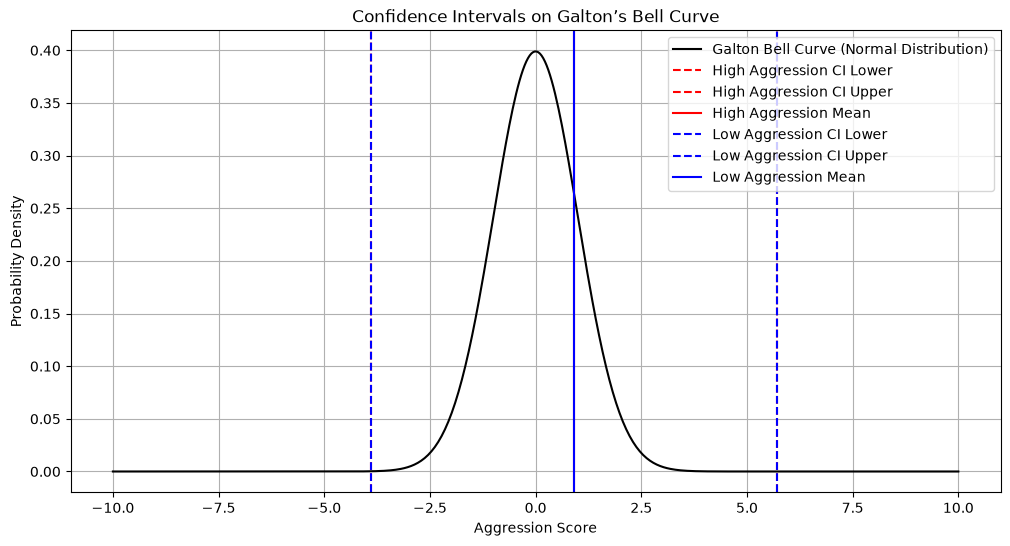

In [156]:
# CI midpoints (means)
high_aggression_mean_pltci = (ci_low_high + ci_upp_high) / 2
low__aggression_mean_plyci  = (ci_low_high + ci_upp_high) / 2

# Galton bell curve (standard normal)
x = np.linspace(-10, 10, 500)
y = norm.pdf(x, 0, 1)

plt.figure(figsize=(12, 6))
plt.plot(x, y, label="Galton Bell Curve (Normal Distribution)", color="black")

# Plot CI ranges
plt.axvline(ci_low_high, color='red', linestyle='--', label='High Aggression CI Lower')
plt.axvline(ci_upp_high, color='red', linestyle='--', label='High Aggression CI Upper')
plt.axvline(high_aggression_mean_pltci, color='red', linestyle='-', label='High Aggression Mean')

plt.axvline(ci_low_high, color='blue', linestyle='--', label='Low Aggression CI Lower')
plt.axvline(ci_upp_high, color='blue', linestyle='--', label='Low Aggression CI Upper')
plt.axvline(low__aggression_mean_plyci, color='blue', linestyle='-', label='Low Aggression Mean')

# Add Labels
plt.title("Confidence Intervals on Galton’s Bell Curve")
plt.xlabel("Aggression Score")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)

plt.show()

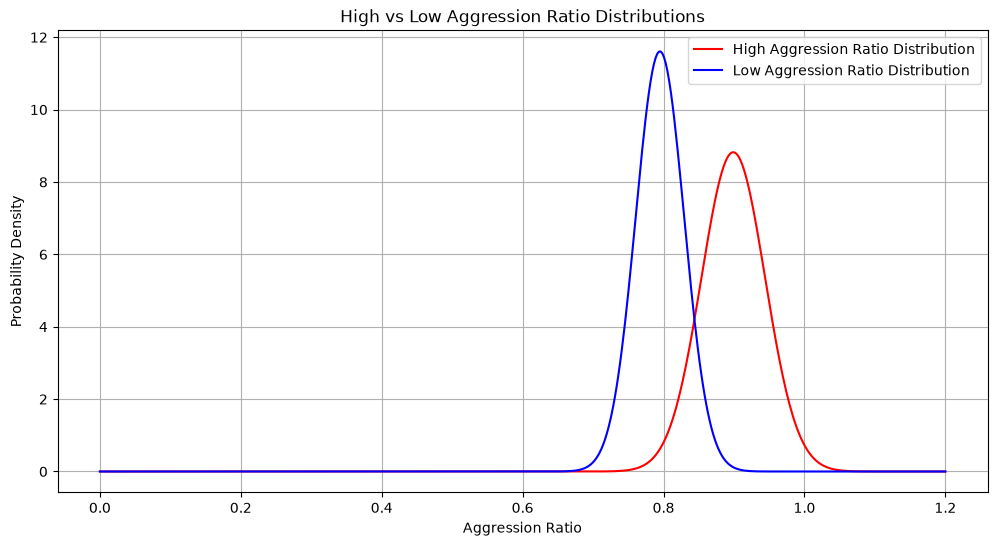

In [157]:
high_aggression_sd_plt_c = high_aggression_std
low_aggression_sd_plt_c = low_aggression_std

# X range
x = np.linspace(0, 1.2, 500)

# PDFs
high_pdf = norm.pdf(x, high_aggression_mean, high_aggression_sd_plt_c)
low_pdf  = norm.pdf(x, low_aggression_mean, low_aggression_sd_plt_c)

plt.figure(figsize=(12,6))

# Plot curves
plt.plot(x, high_pdf, color='red', label='High Aggression Ratio Distribution')
plt.plot(x, low_pdf, color='blue', label='Low Aggression Ratio Distribution')

# Labels
plt.title("High vs Low Aggression Ratio Distributions")
plt.xlabel("Aggression Ratio")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)

plt.show()

<h4> Create visuals for save efficiency </h4>

In [158]:
# calculation confidence interval goalkeeper save efficiency
ci_low, ci_upp = stm._zconfint_generic(high_save_mean, high_save_n / math.sqrt(high_save_n), alpha=0.05, alternative='two-sided') # 95% confidence interval alpha=0.05 or 5%
print("CI high save efficiency goalkeepers: %.2f to %.2f" % (ci_low, ci_upp)) 

CI high save efficiency goalkeepers: -4.70 to 4.91


In [159]:
# calculation confidence interval goalkeeper save efficiency
ci_low, ci_upp = stm._zconfint_generic(low_save_mean, low_save_n / math.sqrt(low_save_n), alpha=0.05, alternative='two-sided') # 95% confidence interval alpha=0.05 or 5%
print("CI low save efficiency goalkeepers: %.2f to %.2f" % (ci_low, ci_upp))

CI low save efficiency goalkeepers: -4.74 to 4.86


In [160]:
# High save CI
ci_low_high_s, ci_upp_high_s = stm._zconfint_generic(
    high_save_mean,
    high_save_n / math.sqrt(high_save_n),
    alpha=0.05,
    alternative='two-sided'
)

# Low save CI
ci_low_low_s, ci_upp_low_s = stm._zconfint_generic(
    low_save_mean,
    low_save_n / math.sqrt(low_save_n),
    alpha=0.05,
    alternative='two-sided'
)

# Build CI table
ci_table_save = pd.DataFrame({
    "Group": ["High Save", "Low Save"],
    "CI Lower": [ci_low_high_s, ci_low_low_s],
    "CI Upper": [ci_upp_high_s, ci_upp_low_s]
})

print(ci_table_save)

       Group  CI Lower  CI Upper
0  High Save -4.695434  4.906390
1   Low Save -4.744405  4.857419


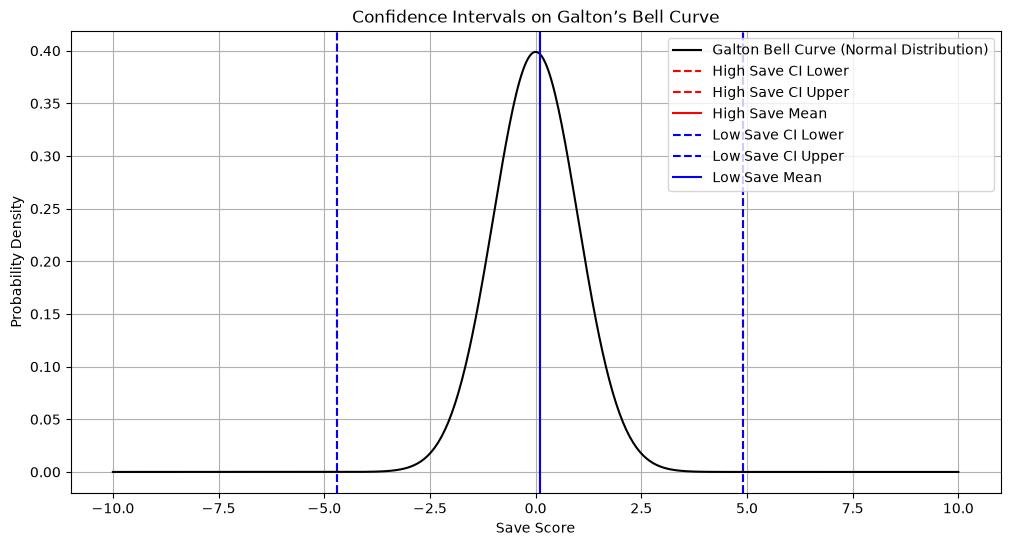

In [161]:
# CI midpoints (means) - save efficiency
high_save_mean_pltci = (ci_low_high_s + ci_upp_high_s) / 2
low__save_mean_plyci  = (ci_low_high_s + ci_upp_high_s) / 2

# Galton bell curve (standard normal)
x = np.linspace(-10, 10, 500)
y = norm.pdf(x, 0, 1)

plt.figure(figsize=(12, 6))
plt.plot(x, y, label="Galton Bell Curve (Normal Distribution)", color="black")

# Plot CI ranges
plt.axvline(ci_low_high_s, color='red', linestyle='--', label='High Save CI Lower')
plt.axvline(ci_upp_high_s, color='red', linestyle='--', label='High Save CI Upper')
plt.axvline(high_save_mean_pltci, color='red', linestyle='-', label='High Save Mean')

plt.axvline(ci_low_high_s, color='blue', linestyle='--', label='Low Save CI Lower')
plt.axvline(ci_upp_high_s, color='blue', linestyle='--', label='Low Save CI Upper')
plt.axvline(low__save_mean_plyci, color='blue', linestyle='-', label='Low Save Mean')

# Add Labels
plt.title("Confidence Intervals on Galton’s Bell Curve")
plt.xlabel("Save Score")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)

plt.show()

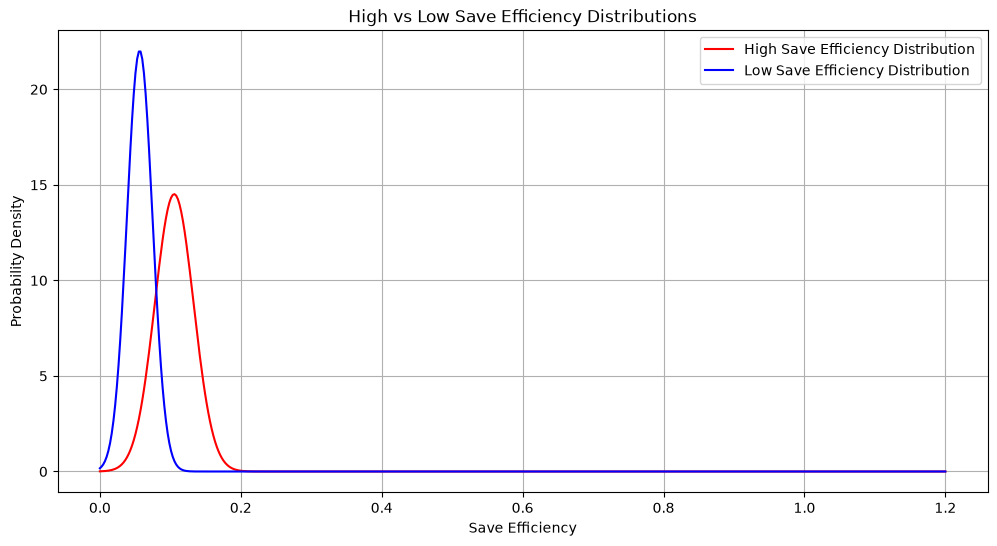

In [162]:
high_save_sd_plt_c = high_save_std
low_save_sd_plt_c = low_save_std

# X range
x = np.linspace(0, 1.2, 500)

# PDFs
s_high_pdf = norm.pdf(x, high_save_mean, high_save_sd_plt_c)
s_low_pdf  = norm.pdf(x, low_save_mean, low_save_sd_plt_c)

plt.figure(figsize=(12,6))

# Plot curves
plt.plot(x, s_high_pdf, color='red', label='High Save Efficiency Distribution')
plt.plot(x, s_low_pdf, color='blue', label='Low Save Efficiency Distribution')

# Labels
plt.title("High vs Low Save Efficiency Distributions")
plt.xlabel("Save Efficiency")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)

plt.show()

In [163]:
# One-sample t-test analysis - Aggression Ratio - High

# Population mean - high aggression
population_mean_high_a = high_aggression["Aggression_Ratio"].mean()

# One-sample t-test - high aggression
t_stat, p_value = stats.ttest_1samp(high_aggression["Aggression_Ratio"], population_mean_high_a)

print("One-sample t-test: aggression ratio high")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  p-value = {p_value:.4f}")
print(f"Population mean = {population_mean_high_a:.4f}")
print(f"Sample mean = {high_aggression["Aggression_Ratio"].mean():.4f}")

One-sample t-test: aggression ratio high
  t-statistic = 0.0000
  p-value = 1.0000
Population mean = 0.8990
Sample mean = 0.8990


In [164]:
# One-sample t-test analysis - Aggression Ratio - Low

# Population mean - low aggression
population_mean_low_a = low_aggression["Aggression_Ratio"].mean()

# One-sample t-test - high aggression
t_stat, p_value = stats.ttest_1samp(low_aggression["Aggression_Ratio"], population_mean_low_a)

print("One-sample t-test: aggression ratio low")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  p-value = {p_value:.4f}")
print(f"Population mean = {population_mean_low_a:.4f}")
print(f"Sample mean = {low_aggression["Aggression_Ratio"].mean():.4f}")

One-sample t-test: aggression ratio low
  t-statistic = 0.0000
  p-value = 1.0000
Population mean = 0.7949
Sample mean = 0.7949


In [165]:
# One-sample t-test analysis - Save Efficiency - High

# Population mean - high save
population_mean_save_h = high_save["Save_Efficiency"].mean()

# One-sample t-test - high aggression
t_stat, p_value = stats.ttest_1samp(high_save["Save_Efficiency"], population_mean_save_h)

print("One-sample t-test: save efficiency high")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  p-value = {p_value:.4f}")
print(f"Population mean = {population_mean_save_h:.4f}")
print(f"Sample mean = {high_save["Save_Efficiency"].mean():.4f}")

One-sample t-test: save efficiency high
  t-statistic = 0.0000
  p-value = 1.0000
Population mean = 0.1055
Sample mean = 0.1055


In [166]:
# One-sample t-test analysis - Save Efficiency - Low

# Population mean - Low save
population_mean_save_l = low_save["Save_Efficiency"].mean()

# One-sample t-test - high aggression
t_stat, p_value = stats.ttest_1samp(low_save["Save_Efficiency"], population_mean_save_l)

print("One-sample t-test: save efficiency low")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  p-value = {p_value:.4f}")
print(f"Population mean = {population_mean_save_l:.4f}")
print(f"Sample mean = {low_save["Save_Efficiency"].mean():.4f}")

One-sample t-test: save efficiency low
  t-statistic = 0.0000
  p-value = 1.0000
Population mean = 0.0565
Sample mean = 0.0565


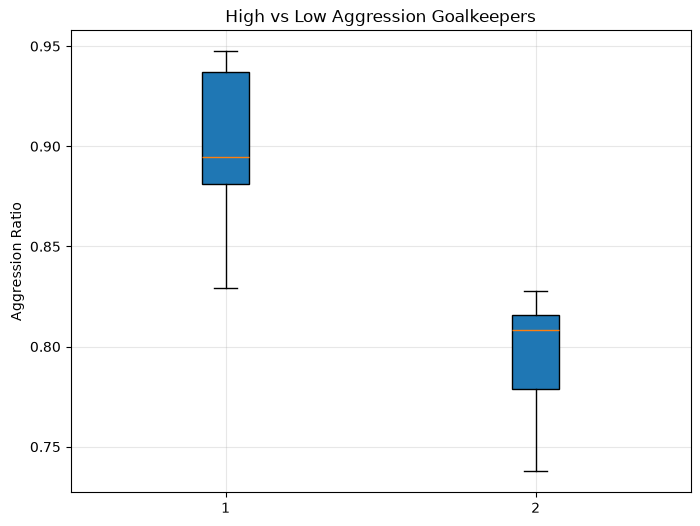

In [167]:
plt.figure(figsize=(8,6))
plt.boxplot(
    [high_aggression["Aggression_Ratio"], low_aggression["Aggression_Ratio"]],
    label=["High Aggression", "Low Aggression"],
    patch_artist=True
)

plt.title("High vs Low Aggression Goalkeepers")
plt.ylabel("Aggression Ratio")
plt.grid(alpha=0.3)
plt.show()

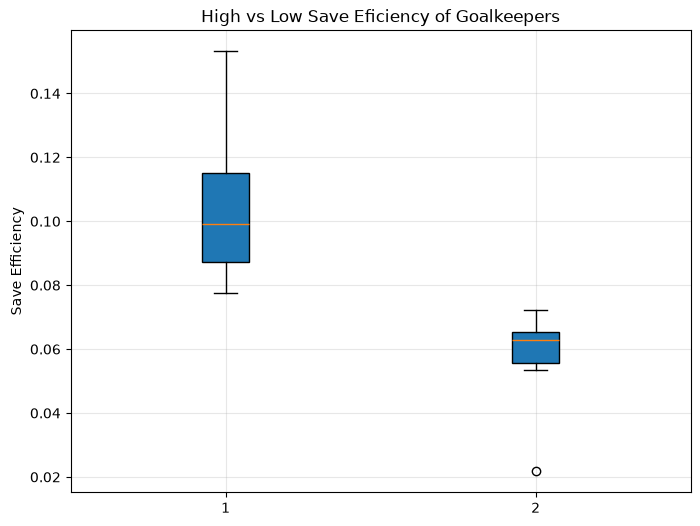

In [168]:
plt.figure(figsize=(8,6))
plt.boxplot(
    [high_save["Save_Efficiency"], low_save["Save_Efficiency"]],
    label=["High Save Efficiency", "Low Save Efficiency"],
    patch_artist=True
)

plt.title("High vs Low Save Eficiency of Goalkeepers")
plt.ylabel("Save Efficiency")
plt.grid(alpha=0.3)
plt.show()

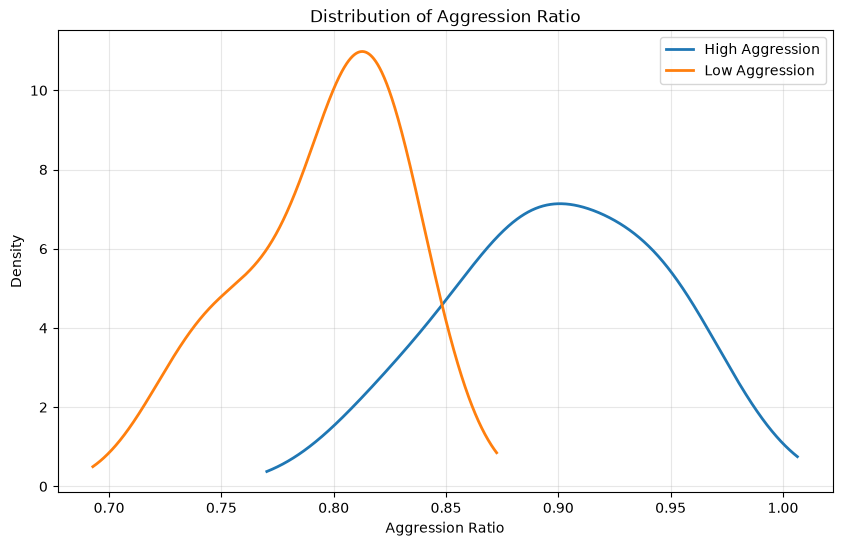

In [169]:
plt.figure(figsize=(10,6))

high_aggression["Aggression_Ratio"].plot(kind='kde', label='High Aggression', linewidth=2)
low_aggression["Aggression_Ratio"].plot(kind='kde', label='Low Aggression', linewidth=2)

plt.title("Distribution of Aggression Ratio")
plt.xlabel("Aggression Ratio")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

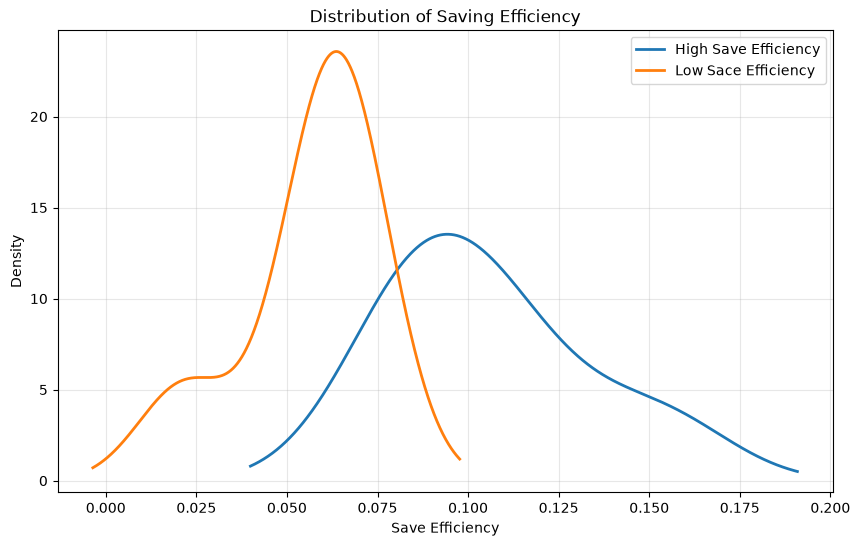

In [170]:
plt.figure(figsize=(10,6))

high_save["Save_Efficiency"].plot(kind='kde', label='High Save Efficiency', linewidth=2)
low_save["Save_Efficiency"].plot(kind='kde', label='Low Sace Efficiency', linewidth=2)

plt.title("Distribution of Saving Efficiency")
plt.xlabel("Save Efficiency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [171]:
# Two-sample t-test (independent samples) - Aggression Ratio
t_stat, p_value = stats.ttest_ind(
    high_aggression["Aggression_Ratio"],
    low_aggression["Aggression_Ratio"],
    equal_var=False  # Welch's t-test (safer when variances differ)
)

print("Two-sample t-test (High vs Low Aggression):")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  p-value = {p_value:.4f}")

Two-sample t-test (High vs Low Aggression):
  t-statistic = 4.4912
  p-value = 0.0014


In [172]:
# Two-sample t-test (independent samples) - Save Efficiency
t_stat, p_value = stats.ttest_ind(
    high_save["Save_Efficiency"],
    low_save["Save_Efficiency"],
    equal_var=False  # Welch's t-test (safer when variances differ)
)

print("Two-sample t-test (High vs Low Saving Efficiency):")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  p-value = {p_value:.4f}")

Two-sample t-test (High vs Low Saving Efficiency):
  t-statistic = 3.6443
  p-value = 0.0057


Cohen’s d is a measure of effect size. It tells me how big the difference is between two groups, expressed in standard deviation units.
Where a t‑test tells me whether a difference is statistically significant,
Cohen’s d tells me whether the difference is meaningful.

This will tell me how far apart are the two group means, relative to the spread of the data

Interpretation guide:
- 0.2 = small
- <strong>0.5 = medium</strong>
- 0.8+ = large

In [173]:
# What does cohen's d measure? This function measures how big is the difference between the two samples
mean_high_aggression = high_aggression["Aggression_Ratio"].mean()
mean_low_aggression = low_aggression["Aggression_Ratio"].mean()

std_high_aggression = high_aggression["Aggression_Ratio"].std()
std_low_aggression = low_aggression["Aggression_Ratio"].std()

# Standard deviation
n_high_aggression = len(high_aggression)
n_low_aggression = len(low_aggression)

pooled_sd_a = (((n_high_aggression - 1)*std_high**2 + (n_low_aggression - 1)*std_low**2) / (n_high_aggression + n_low_aggression - 2))**0.5

cohens_d_a = (mean_high_aggression - mean_low_aggression) / pooled_sd_a

print(f"Cohen's d = {cohens_d_a:.4f}")
print("This score falls into the 'MEDIUM' size variance")

Cohen's d = 3.1343
This score falls into the 'MEDIUM' size variance


In [174]:
# What does cohen's d measure? This function measures how big is the difference between the two samples
mean_high_save = high_save["Save_Efficiency"].mean()
mean_low_Save = low_save["Save_Efficiency"].mean()

std_high_save = high_save["Save_Efficiency"].std()
std_low_save = low_save["Save_Efficiency"].std()

# Standard deviation
n_high_save = len(high_save)
n_low_save = len(low_save)

pooled_sd_s = (((n_high_save - 1)*std_high**2 + (n_low_save - 1)*std_low**2) / (n_high_save + n_low_save - 2))**0.5

cohens_d_s = (mean_high_save - mean_low_Save) / pooled_sd_s

print(f"Cohen's d = {cohens_d_s:.4f}")
print("This score falls into the 'LARGE' size variance")

Cohen's d = 1.4743
This score falls into the 'LARGE' size variance


<h4>Scatter Plot: Aggression vs Save Efficiency</h4>

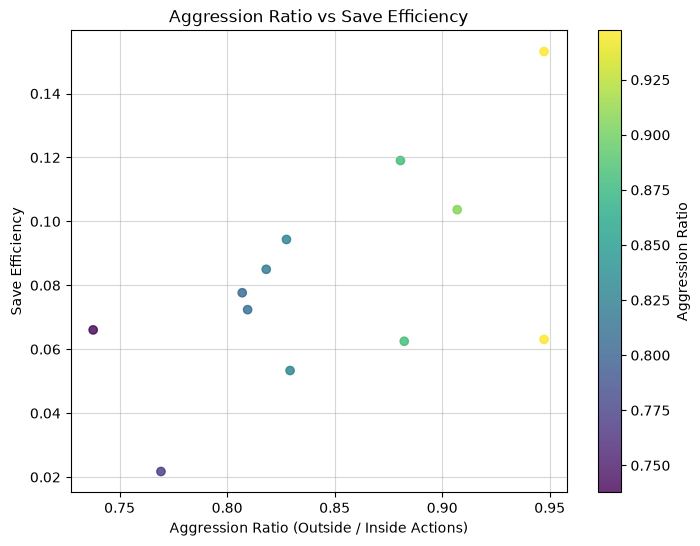

In [175]:
plt.figure(figsize=(8,6))
plt.scatter(
    gk_sample["Aggression_Ratio"], 
    gk_sample["Save_Efficiency"],
    c=gk_sample["Aggression_Ratio"],
    cmap="viridis",
    alpha=0.8)

plt.title("Aggression Ratio vs Save Efficiency")
plt.xlabel("Aggression Ratio (Outside / Inside Actions)")
plt.ylabel("Save Efficiency")
plt.grid(alpha=0.5)
plt.colorbar(label='Aggression Ratio')
plt.show()


In [176]:
#create one table
# create high and low grouping of goalkeepers - aggression
aggression_table = pd.DataFrame({
    "High_Aggression": high_aggression["Aggression_Ratio"],
    "Low_Aggression": low_aggression["Aggression_Ratio"]
})



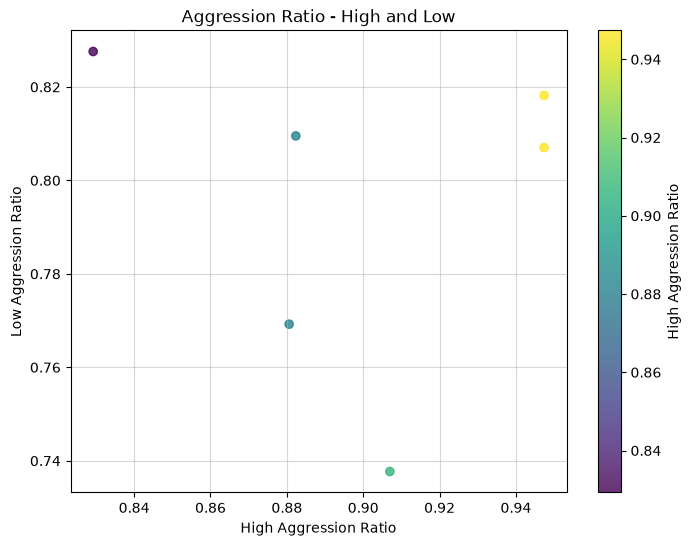

In [177]:
# plot high vs Low aggression goalkeepers
plt.figure(figsize=(8,6))

plt.scatter(
    high_aggression["Aggression_Ratio"], 
    low_aggression["Aggression_Ratio"],
    c=high_aggression["Aggression_Ratio"],
    cmap="viridis",
    alpha=0.8
)

plt.title("Aggression Ratio - High and Low")
plt.xlabel("High Aggression Ratio")
plt.ylabel("Low Aggression Ratio")
plt.grid(alpha=0.5)
plt.colorbar(label='High Aggression Ratio')
plt.show()


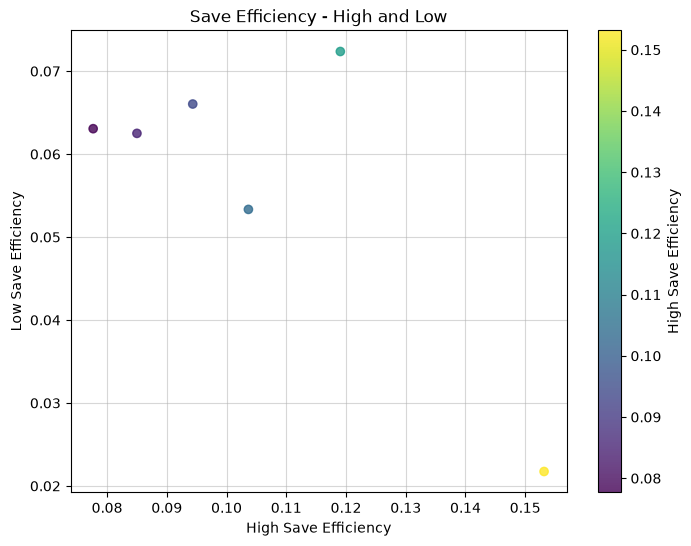

In [178]:
# plot high vs Low saveing efficiency goalkeepers
plt.figure(figsize=(8,6))

plt.scatter(
    high_save["Save_Efficiency"], 
    low_save["Save_Efficiency"],
    c=high_save["Save_Efficiency"],
    cmap="viridis",
    alpha=0.8
)

plt.title("Save Efficiency - High and Low")
plt.xlabel("High Save Efficiency")
plt.ylabel("Low Save Efficiency")
plt.grid(alpha=0.5)
plt.colorbar(label='High Save Efficiency')
plt.show()

<h4>Histogram Comparison</h4>

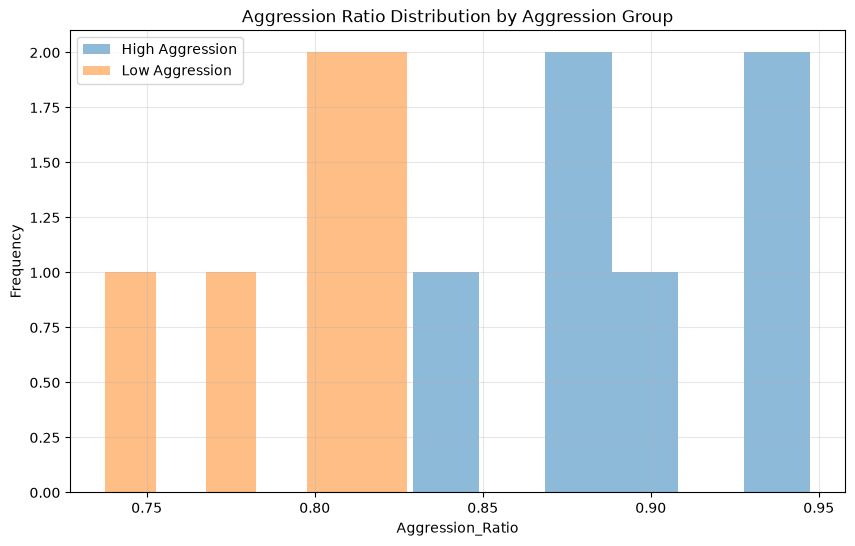

In [179]:
plt.figure(figsize=(10,6))

plt.hist(high_aggression["Aggression_Ratio"], bins=6, alpha=0.5, label="High Aggression")
plt.hist(low_aggression["Aggression_Ratio"], bins=6, alpha=0.5, label="Low Aggression")

plt.title("Aggression Ratio Distribution by Aggression Group")
plt.xlabel("Aggression_Ratio")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

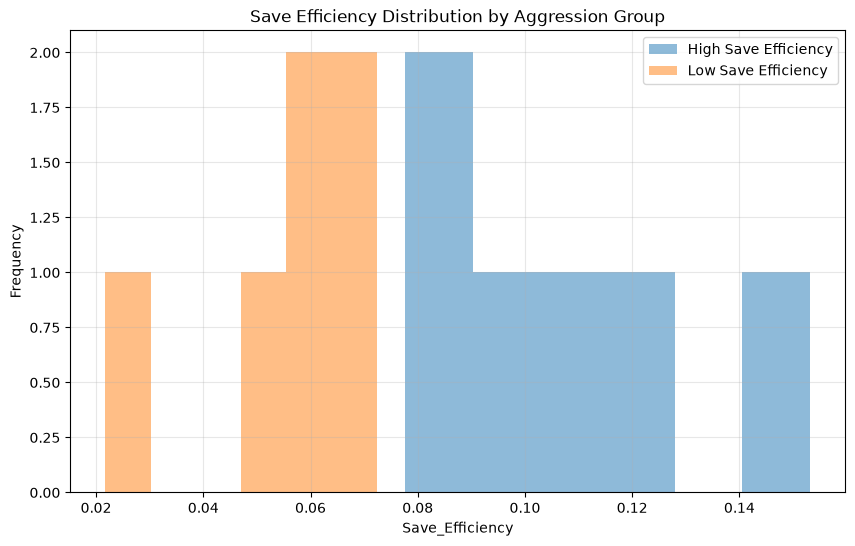

In [180]:
plt.figure(figsize=(10,6))

plt.hist(high_save["Save_Efficiency"], bins=6, alpha=0.5, label="High Save Efficiency")
plt.hist(low_save["Save_Efficiency"], bins=6, alpha=0.5, label="Low Save Efficiency")

plt.title("Save Efficiency Distribution by Aggression Group")
plt.xlabel("Save_Efficiency")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<h4>Now for the pretty data</h4>

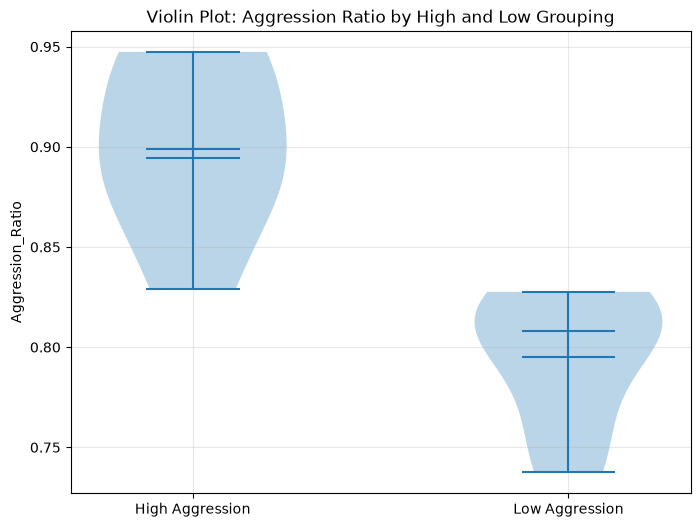

In [181]:
plt.figure(figsize=(8,6))
plt.violinplot(
    [high_aggression["Aggression_Ratio"], low_aggression["Aggression_Ratio"]],
    showmeans=True,
    showmedians=True
)

plt.xticks([1, 2], ["High Aggression", "Low Aggression"])
plt.title("Violin Plot: Aggression Ratio by High and Low Grouping")
plt.ylabel("Aggression_Ratio")
plt.grid(alpha=0.3)
plt.show()


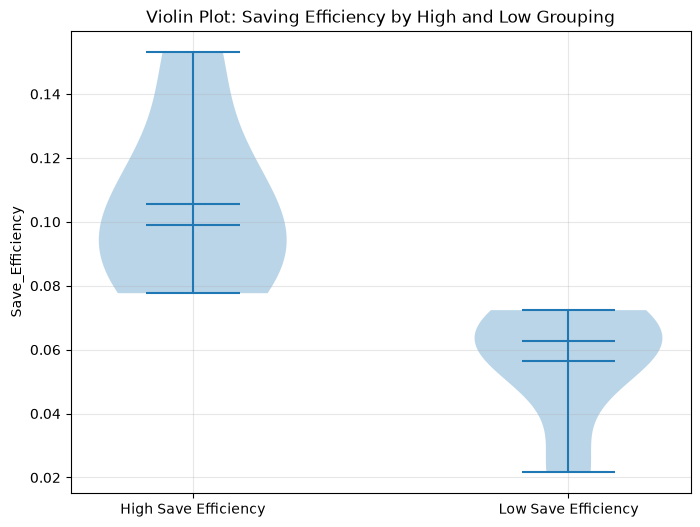

In [182]:
plt.figure(figsize=(8,6))
plt.violinplot(
    [high_save["Save_Efficiency"], low_save["Save_Efficiency"]],
    showmeans=True,
    showmedians=True
)

plt.xticks([1, 2], ["High Save Efficiency", "Low Save Efficiency"])
plt.title("Violin Plot: Saving Efficiency by High and Low Grouping")
plt.ylabel("Save_Efficiency")
plt.grid(alpha=0.3)
plt.show()

In [183]:
# Hypothesis Testing - High Aggression

# perform one-sample t-test
# null hypothesis: population mean = 0.8990
# alternative hypothesis: population mean > 0.8990 (in the function below, note the argument 'greater')
t_stats, p_val = st.ttest_1samp(high_aggression["Aggression_Ratio"], 0.8990, alternative='greater')
print("\n Computing t* ...")
print("\t t-statistic (t*): %.2f" % t_stats)

print("\n Computing p-value ...")
print("\t p-value: %.4f" % p_val)

print("\n Conclusion:")
if p_val <= 0.05:
    print("\t We reject the null hypothesis.")
else:
    print("\t We accept the null hypothesis.")


 Computing t* ...
	 t-statistic (t*): -0.00

 Computing p-value ...
	 p-value: 0.5002

 Conclusion:
	 We accept the null hypothesis.


In [184]:
# Hypothesis Testing - Low Aggression

# perform one-sample t-test
# null hypothesis: population mean = 0.7949
# alternative hypothesis: population mean > 0.7949 (in the function below, note the argument 'greater')
t_stats, p_val = st.ttest_1samp(low_aggression["Aggression_Ratio"], 0.7949, alternative='greater')
print("\n Computing t* ...")
print("\t t-statistic (t*): %.2f" % t_stats)

print("\n Computing p-value ...")
print("\t p-value: %.4f" % p_val)

print("\n Conclusion:")
if p_val <= 0.05:
    print("\t We reject the null hypothesis.")
else:
    print("\t We accept the null hypothesis.")


 Computing t* ...
	 t-statistic (t*): -0.00

 Computing p-value ...
	 p-value: 0.5007

 Conclusion:
	 We accept the null hypothesis.


Result interpretation: High and Low Aggression

- The aggression ratio that was tested is not significantly higher or lower than the benchmark chosen.
- Statistically, the goalkeepers’ aggression ratio is exactly what I would expect under the null hypothesis.
- There is no detectable deviation in the direction that I might have expected.
- The sample mean is statistically indistinguishable from the hypothesized mean.

In [185]:
# Hypothesis Testing - High Save

# perform one-sample t-test
# null hypothesis: population mean = 0.1055
# alternative hypothesis: population mean > 0.1055 (in the function below, note the argument 'greater')
t_stats, p_val = st.ttest_1samp(high_save["Save_Efficiency"], 0.1055, alternative='greater')
print("\n Computing t* ...")
print("\t t-statistic (t*): %.2f" % t_stats)

print("\n Computing p-value ...")
print("\t p-value: %.4f" % p_val)

print("\n Conclusion:")
if p_val <= 0.05:
    print("\t We reject the null hypothesis.")
else:
    print("\t We accept the null hypothesis.")


 Computing t* ...
	 t-statistic (t*): -0.00

 Computing p-value ...
	 p-value: 0.5007

 Conclusion:
	 We accept the null hypothesis.


In [186]:
# Hypothesis Testing - Low Save

# perform one-sample t-test
# null hypothesis: population mean = 0.0565
# alternative hypothesis: population mean > 0.0565 (in the function below, note the argument 'greater')
t_stats, p_val = st.ttest_1samp(low_save["Save_Efficiency"], 0.0565, alternative='greater')
print("\n Computing t* ...")
print("\t t-statistic (t*): %.2f" % t_stats)

print("\n Computing p-value ...")
print("\t p-value: %.4f" % p_val)

print("\n Conclusion:")
if p_val <= 0.05:
    print("\t We reject the null hypothesis.")
else:
    print("\t We accept the null hypothesis.")


 Computing t* ...
	 t-statistic (t*): 0.00

 Computing p-value ...
	 p-value: 0.4996

 Conclusion:
	 We accept the null hypothesis.
